## 1. Install packages and download the data

### 1.1 Install and import the Python packages

In [ ]:
# micromamba env create -f environment.yml

In [1]:
# Import the python packages. Rerun this code again if you encounter an error on xarray_schema.
import scanpy as sc
import pandas as pd
import numpy as np
import h5py
import anndata as ad
import matplotlib.pyplot as plt
import warnings
import os
import squidpy as sq
import spatialdata as sd
import spatialdata_io as sio
import spatialdata_plot

%load_ext autoreload
%autoreload 2

warnings.filterwarnings("ignore")

/home/duydao/micromamba/envs/spatial_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Xenium data visualization and analysis (single sample)

### SpatialData overview

SpatialData is a flexible framework for loading and analyzing Xenium data. It organizes data into 5 main object types:

- **Images** — the Xenium morphology or H&E/IF images (e.g. `morphology_focus` OME-TIFFs).
- **Labels** — segmentation masks provided by Xenium (cell and nucleus labels).
- **Points** — transcript locations (`transcripts.parquet`).
- **Shapes** — cell/nucleus segmentation boundaries from Xenium onboard analysis.
- **Tables** — the gene expression count matrix (cells x genes) as an `AnnData` object, analyzable like standard single-cell data.

### 2.1 Load the data

In [2]:
# Build the SpatialData object directly from the raw Xenium bundle
sdata = sio.xenium("../../data/xenium_prime_5k/")

# Fix the string-based cell/nucleus boundary index for napari compatibility
for shape_name in ["cell_boundaries", "nucleus_boundaries"]:
    if shape_name in sdata.shapes:
        boundaries = sdata.shapes[shape_name]
        boundaries["cell_id_str"] = boundaries.index.astype(str)
        sdata.shapes[shape_name] = boundaries.reset_index(drop=True)

sdata.write("../../data/xenium_prime_5k.zarr", overwrite=True)
sdata

SpatialData object, with associated Zarr store: /home/duydao/Projects/xenium_lung/data/xenium_prime_5k.zarr
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 43270, 26720), (3, 21635, 13360), (3, 10817, 6680), (3, 5408, 3340), (3, 2704, 1670)
│     └── 'morphology_focus': DataTree[cyx] (4, 37348, 54086), (4, 18674, 27043), (4, 9337, 13521), (4, 4668, 6760), (4, 2334, 3380)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (37348, 54086), (18674, 27043), (9337, 13521), (4668, 6760), (2334, 3380)
│     └── 'nucleus_labels': DataTree[yx] (37348, 54086), (18674, 27043), (9337, 13521), (4668, 6760), (2334, 3380)
├── Points
│     └── 'transcripts': DataFrame with shape: (10470389039, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (278328, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (277935, 3) (2D shapes)
└── Tables
      └── 'table': AnnData (278328, 5001)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), m

### 2.2 Transcript and cell plotting functions

The "cell_boundaries" shapes give the spatial location and shape of cells, while the "table" object holds gene expression. We link them with `set_table_annotates_spatialelement`. For cells, use `render_shapes`; for transcripts, use `render_points`. See the [spatialdata plotting docs](https://spatialdata.scverse.org/projects/plot/en/stable/plotting.html) for details.

WARNING  render_shapes: Found 1 NaN values in color data. These observations will be colored with the 'na_color'.  


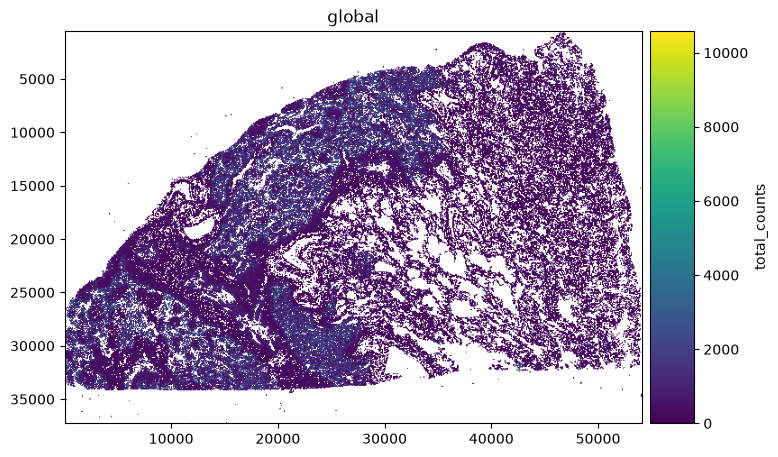

In [3]:
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

# The x and y axis are pixel coordinates
sdata.pl.render_shapes("cell_boundaries", color="total_counts").pl.show()

In [ ]:
# EPCAM (epithelial/tumor) and CD3E (T cell) are both present in this gene panel
sdata.pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["EPCAM", "CD3E"],
    palette=["orange", "blue"],
).pl.show()

### 2.3 Select sub-region of interest (optional)

There are two ways to select sub-regions of interest:

1. By coordinates
2. By cell IDs

The cells below are templates: export a coordinate polygon or a list of cell IDs from napari for your own region of interest, then update the placeholder values/paths before uncommenting and running.

In [ ]:
# Template: replace with coordinates exported from napari, then uncomment to run
# from spatialdata import bounding_box_query
#
# scale = 1 / 0.2125  # microns -> pixels
# min_x, min_y, max_x, max_y = 0, 0, 0, 0  # <- your coordinates in microns
#
# cropped_sdata = bounding_box_query(
#     sdata,
#     min_coordinate=[min_x * scale, min_y * scale],
#     max_coordinate=[max_x * scale, max_y * scale],
#     axes=("x", "y"),
#     target_coordinate_system="global",
# )
# cropped_sdata.tables["table"].obs["region"] = "cell_boundaries"
# cropped_sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")
# cropped_sdata.pl.render_shapes("cell_boundaries", color="total_counts").pl.show()

In [ ]:
# Template: replace with a CSV of selected cell IDs exported from napari, then uncomment to run
# select_cells = pd.read_csv("../../data/my_selection_cell_ids.csv")
#
# subset_sdata = sd.match_sdata_to_table(
#     sdata,
#     table=sdata["table"][sdata["table"].obs["cell_id"].isin(select_cells["Cell ID"])],
#     table_name="table",
#     how="right",
# )
# subset_sdata.pl.render_shapes("cell_boundaries", color="total_counts").pl.show()

### 2.4 Downstream analysis of count matrix (sdata['table'])

The first step is QC to remove cells with low transcript counts. We plot the distribution of transcript counts per cell to pick a cutoff (subjective, no gold-standard rule).

We shallow-copy with `adata = sdata['table']` — changes to `adata` are reflected in `sdata['table']`. To keep a separate copy, use `adata = sdata['table'].copy()`.

In [ ]:
adata = sdata["table"]
# We keep the raw counts in a layer for later use
adata.layers["counts"] = adata.X.copy()

In [ ]:
fig = plt.hist(adata.obs["total_counts"], range=(0, 200), bins=100)
plt.axvline(x=20, color="r", linestyle="--")  # Adjust the cutoff based on the histogram

plt.xlabel("Transcripts per cell")
plt.ylabel("Number of cells")

In [ ]:
# Based on the histogram above, we use 20 transcripts as the lower cutoff
thres = np.quantile(adata.obs["total_counts"], 0.98)
sc.pp.filter_cells(adata, min_counts=20)
sc.pp.filter_cells(adata, max_counts=thres)

# We also filter out genes that are rarely expressed
sc.pp.filter_genes(adata, min_cells=100)

In [ ]:
%%time
# This is a Xenium Prime panel (>5k genes), so we can find the top 2k highly variable genes
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)

In [ ]:
%%time
# Log Normalization
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

In [ ]:
%%time
# We don't center the data here since PCA handles centering, keeping X sparse for memory efficiency
sc.pp.scale(adata, zero_center=False, max_value=10)

In [ ]:
%%time
# PCA for dimension reduction, followed by UMAP/neighbors for downstream analysis
sc.pp.pca(adata, n_comps=30)
sc.pp.neighbors(adata, metric="cosine")
# igraph flavor scales better on larger Xenium datasets. Resolution controls the number of clusters
sc.tl.leiden(adata, flavor="igraph", n_iterations=-1, resolution=0.5)

In [ ]:
%%time
# Can take a while on the full sample
sc.tl.umap(adata)

In [ ]:
sc.pl.umap(adata, color="leiden")

#### Plot clustering results spatially in the slide

In [ ]:
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

sdata.pl.render_shapes("cell_boundaries", color="leiden").pl.show(figsize=(12.8, 9.6))

#### Export clustering results (for napari / Xenium Explorer)

Save clustering results in a CSV file with two columns — `cell_id` and `group`.

In [ ]:
clustering_res = adata.obs[["cell_id", "leiden"]]
clustering_res.columns = ["cell_id", "group"]
clustering_res.to_csv("../../data/xenium_prime_5k_clustering.csv", index=False)
clustering_res.head()

#### Find marker genes for each cluster

`sc.tl.rank_genes_groups` finds marker genes per cluster. `pts=True` also returns the percentage of cells expressing each gene. It expects log-normalized data, so we use `layer="lognorm"`.

In [ ]:
sc.tl.rank_genes_groups(adata, groupby="leiden", layer="lognorm", pts=True)

In [ ]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5)

#### Cell annotation based on marker genes in each cluster

Based on the marker genes above, annotate each cluster:

1. Get the marker genes for a cluster.
2. Find associated cell types via a third-party tool, e.g. [Enrichr](https://maayanlab.cloud/Enrichr/).
3. Confirm cell identity using spatial location in napari (together with the H&E image if available).

Below is a template for pulling the full marker gene table for a single cluster — replace `"0"` with the cluster you're investigating.

In [ ]:
cluster_markers = sc.get.rank_genes_groups_df(adata, group="0")
cluster_markers.head(10)

#### Saving the processed data

We save the processed Zarr store for further use in Section 3.

In [ ]:
sdata.write("../../data/xenium_prime_5k_processed.zarr", overwrite=True)

## 3. Additional topics: neighborhood enrichment & spatially variable genes

Here we reuse the single lung sample processed in Section 2 to demonstrate a simple neighborhood enrichment and spatial autocorrelation analysis.

In [ ]:
# Read the processed sample saved at the end of Section 2
sdata = sd.read_zarr("../../data/xenium_prime_5k_processed.zarr")
adata = sdata["table"]

### 3.1 Centrality scores

Centrality measures how "important" a cluster is within the spatial neighborhood graph.

- **Average clustering** — tendency of cluster members to form triangles; high values suggest tight-knit, localized tissue regions.
- **Closeness centrality** — how close a cluster is, on average, to all other clusters; a high value may indicate a mediator role in tissue structure.
- **Degree centrality** — fraction of edges from cluster members that connect to other clusters; high values suggest outward-facing influence.

In [ ]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
sq.gr.centrality_scores(adata, cluster_key="leiden")
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))

### 3.2 Neighborhood enrichment

Neighborhood enrichment scores the proximity of cell clusters on the connectivity graph against a permutation-based null distribution, producing a z-score per cluster pair.

In [ ]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sdata.pl.render_shapes("cell_boundaries", color="leiden").pl.show(ax=ax[1])

### 3.3 Identify spatially variable genes (Moran's I)

A high Moran's I score indicates strong, non-random, spatially clustered gene expression — a useful signal for tissue organization and spatial domains.

In [ ]:
%%time
sq.gr.spatial_autocorr(adata, mode="moran", n_jobs=-1)
adata.uns["moranI"].head(10)

In [ ]:
# Auto-pick the top 2 spatially variable genes instead of hardcoding gene names
top_genes = adata.uns["moranI"].index[:2].tolist()

sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=top_genes,
    shape=None,
    size=2,
    img=False,
    layer="lognorm",
)

Verify these spatially variable genes and cluster assignments visually in napari or Xenium Explorer using the exported `xenium_prime_5k_clustering.csv`.